In [73]:
import cv2
import os
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mediapipe as mp

In [74]:
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

In [75]:
paths0=[]
for dirname, _ , filenames in os.walk("D:\\capstone111\\umpire\\train"):
    for filename in filenames:
        if filename[-4:]=='.jpg':
            paths0 += [(os.path.join(dirname, filename))]
print(paths0[0:3])
paths = random.sample(paths0,200)

['D:\\capstone111\\umpire\\train\\no_action_10.jpg', 'D:\\capstone111\\umpire\\train\\no_action_12.jpg', 'D:\\capstone111\\umpire\\train\\no_action_14.jpg']


In [76]:
names=['no action','no ball','out','six','wide']
names_ab=['no_a','no_b','out_','sixe','wide']
normal_mapping=dict(zip(names,names_ab))
reverse_mapping=dict(zip(names_ab,names))

In [77]:
labels2=[]
paths2=[]
for i,path in enumerate(paths):
    if i%50==0:
        print('i=',i)
    file=path.split('\\')[-1]
    label=path.split('\\')[-2]
    image=cv2.imread(path)
    image=cv2.resize(image, dsize=(400,400))

    with mp_pose.Pose(
        static_image_mode=True,
        model_complexity=2,
        enable_segmentation=True,
        min_detection_confidence=0.1) as pose:
        try:
            results = pose.process(cv2.flip(image,1))
            if results.pose_landmarks: 
                image_hight, image_width, _ = image.shape
                annotated_image = cv2.flip(image.copy(),1)
                mp_drawing.draw_landmarks(
                    annotated_image,
                    results.pose_landmarks,
                    mp_pose.POSE_CONNECTIONS,
                    mp_drawing_styles.get_default_pose_landmarks_style(),
                )

                anno_img=cv2.flip(annotated_image,1)               
                cv2.imwrite(file,anno_img)
                paths2+=[file]
                labels2+=[reverse_mapping[file[0:4]]]
        except:
            continue

i= 0
i= 50
i= 100
i= 150


In [78]:
data=pd.DataFrame(columns=['path','label'])
data['path']=paths2
data['label']=labels2
data.to_csv('data.csv',index=False)
display(data)

,path,label
0,sixes_19.jpg,six
1,no_ball_33.jpg,no ball
2,no_action_10.jpg,no action
3,no_ball_41.jpg,no ball
4,no_action_14.jpg,no action
...,...,...
173,no_action_47.jpg,no action
174,no_action_12.jpg,no action
175,no_ball_77.jpg,no ball
176,sixes_75.jpg,six


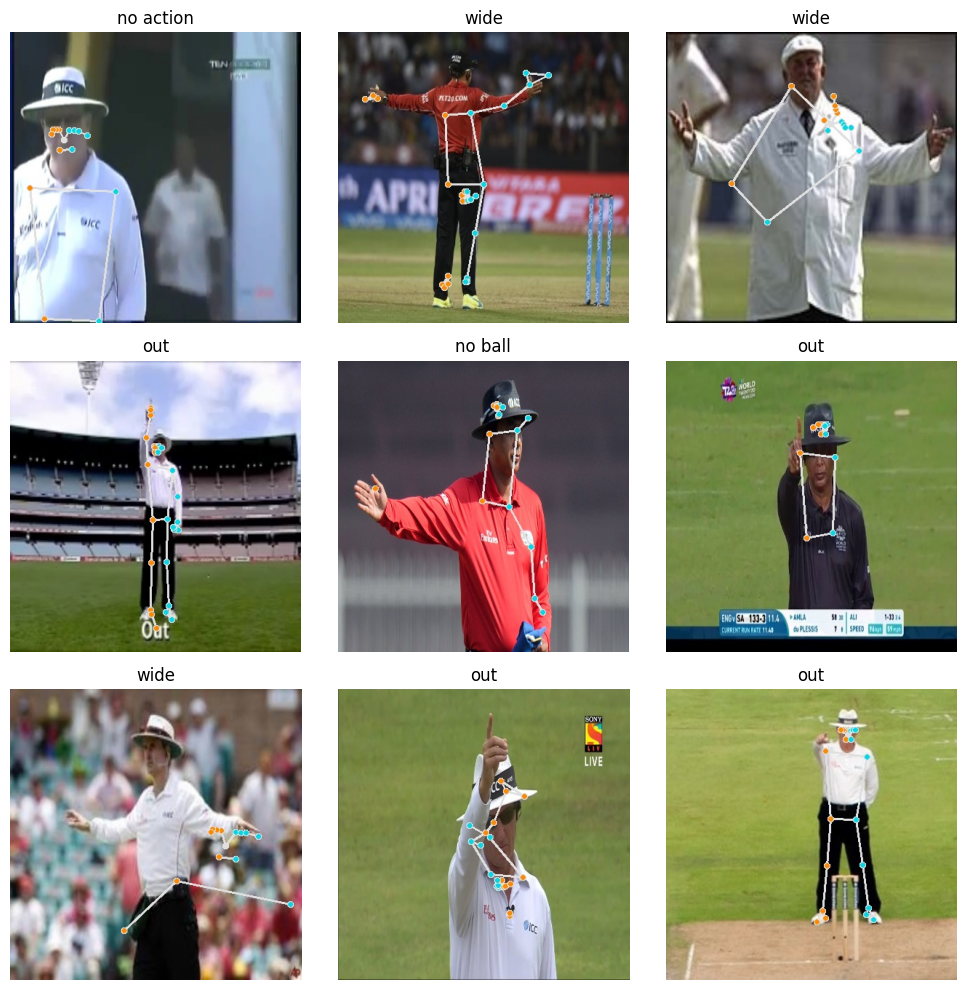

In [79]:
selected_num = random.sample(range(len(data)),9)
fig, axes = plt.subplots(3,3, figsize=(10,10))
for i, ax in enumerate(axes.flat):
    j=selected_num[i]
    img_path = data.iloc[j,0]
    label=data.iloc[j,1]
    img = plt.imread(img_path)  
    ax.imshow(img)              
    ax.axis('off')             
    ax.set_title(label) 
plt.tight_layout() 
plt.show()

,path,label
0,sixes_19.jpg,six
1,no_ball_33.jpg,no ball
2,no_action_10.jpg,no action
3,no_ball_41.jpg,no ball
4,no_action_14.jpg,no action
...,...,...
213,C:\Users\V.Sree Chaitran\Downloads\legbye_3.jpg,legbyes
214,C:\Users\V.Sree Chaitran\Downloads\legbye_4.jpg,legbyes
215,C:\Users\V.Sree Chaitran\Downloads\legbye_5.jpg,legbyes
216,C:\Users\V.Sree Chaitran\Downloads\legbye_6.jpg,legbyes


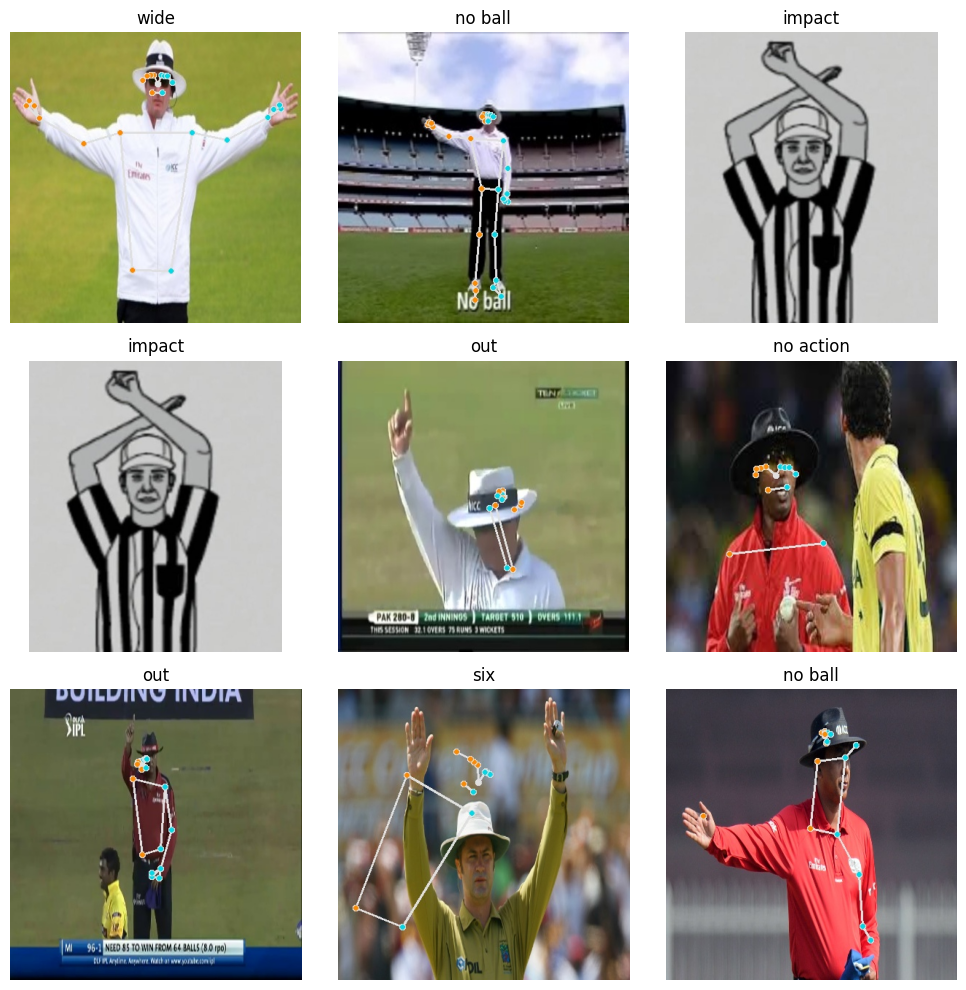

In [83]:

impact_paths = ["C:\\Users\\V.Sree Chaitran\\Downloads\\imapct_2.jpg", "C:\\Users\\V.Sree Chaitran\\Downloads\\imapct_3.jpg", "C:\\Users\\V.Sree Chaitran\\Downloads\\impact_4.jpg"]
legbyes_paths = ["C:\\Users\\V.Sree Chaitran\\Downloads\\legbye_1.jpg", "C:\\Users\\V.Sree Chaitran\\Downloads\\legbye_2.jpg","C:\\Users\\V.Sree Chaitran\\Downloads\\legbye_3.jpg", "C:\\Users\\V.Sree Chaitran\\Downloads\\legbye_4.jpg", "C:\\Users\\V.Sree Chaitran\\Downloads\\legbye_5.jpg", "C:\\Users\\V.Sree Chaitran\\Downloads\\legbye_6.jpg", "C:\\Users\\V.Sree Chaitran\\Downloads\\legbye_7.jpg"]


impact_labels = ['impact'] * len(impact_paths)
legbyes_labels = ['legbyes'] * len(legbyes_paths)


paths2 += impact_paths + legbyes_paths
labels2 += impact_labels + legbyes_labels

# Create DataFrame and save to CSV
data = pd.DataFrame(columns=['path','label'])
data['path'] = paths2
data['label'] = labels2
data.to_csv('data.csv', index=False)
display(data)


selected_num = random.sample(range(len(data)), 9)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    j = selected_num[i]
    img_path = data.iloc[j, 0]
    label = data.iloc[j, 1]
    img = plt.imread(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(label)
plt.tight_layout()
plt.show()
